## Analysis notebook of ovrlpy analysis for publication:

#### Comparison to a Baysor analysis of Xenium-derived mouse brain data.

Louis Kuemmerle from Helmholz Institute Munich kindly provided our research project with a number of Baysor analysis outputs of Xenium's mouse brain data set. 

In this notebook, we want to use ovrlpy to investigate the performance of baysor around detected regions of cell overlap and compare baysor's interpretation of overlapping signal to our tool's.

In [14]:
import matplotlib

cm = 1 / 2.54  # conversion from inch, for plotting

font = {"family": "sans-serif", "weight": "normal", "size": 6}

matplotlib.rc("font", **font)

#### Package import, parameters:

In [1]:
from pathlib import Path

import anndata as ad
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar

kde_bandwidth = 1.0
um_per_pixel = 2.0

coordinate_path = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-baysor/2d_3d_baysor/"
)

datasets = [f for f in coordinate_path.iterdir() if f.suffix == ".h5ad"]

mapmycells_dir = Path(
    "/dh-projects/ag-ishaque/analysis/tiesmeys/data/ovrlpy/mapmycells/xenium-baysor"
)

#### Loading datasets:

There exist 6 Baysor datasets, created with different parameterizations. ([2d-tiled, 2d-non-tiled, 3d-tiled],[with/without segmentation prior])

In [2]:
annotation_csv = pd.read_csv(coordinate_path / "params_dict_readable.csv", index_col=0)

integrated_coordinate_df = ad.read_h5ad(datasets[0]).uns["spots"]

cell_assignment_dfs = {}

for file in datasets:
    with h5py.File(file, "r") as f:
        dataset_name = file.stem[7:]

        params = annotation_csv.loc[
            dataset_name, ["use_3d", "prior-segmentation-confidence", "expand"]
        ]

        # print(params)
        params["use_3d"] = "3d" if params["use_3d"] == "True" else "2d"
        params["expand"] = "expand_" + str(params["expand"])
        params["prior-segmentation-confidence"] = "prior_" + str(
            params["prior-segmentation-confidence"]
        )
        params["tiled"] = (
            "tiled"
            if "not_assigned_due_to_tiling" in f["uns"]["spots"].keys()
            else "not_tiled"
        )

        colname = "cell_id-" + "-".join([str(x) for x in params.values])

        integrated_coordinate_df[colname] = pd.array(
            f["uns"]["spots"]["cell"], dtype=pd.Int64Dtype()
        )

        cell_assignment_dfs[colname] = pd.DataFrame(
            {
                "centroid_x": f["obs"]["centroid_x"],
                "centroid_y": f["obs"]["centroid_y"],
                "celltype": np.array(f["obs"]["ct_majority"]["categories"])[
                    f["obs"]["ct_majority"]["codes"]
                ],
                "score": f["obs"]["ct_majority_cert"],
                "passed_qc": f["obs"]["passed_QC"],
                "n_counts": f["obs"]["n_counts"],
                "n_genes": f["obs"]["n_genes"],
                "area": f["obs"]["area"],
            },
            index=f["obs"]["cell_id"],
        ).astype({"celltype": "category"})

In [3]:
dataset_3d = cell_assignment_dfs["cell_id-3d-prior_0.8-expand_0.0-tiled"]

coordinate_df_3d = (
    integrated_coordinate_df[
        ["Gene", "x", "y", "z", "cell_id-3d-prior_0.8-expand_0.0-tiled"]
    ]
    .rename(columns={"cell_id-3d-prior_0.8-expand_0.0-tiled": "cell_id"})
    .loc[lambda df: df["cell_id"].isin(dataset_3d.index)]
    .copy()
)

counts = (
    coordinate_df_3d.groupby(["Gene", "cell_id"], observed=False).size().to_frame("n")
)

count_mtx_3d = (
    counts.reset_index("Gene")
    .pivot(columns="Gene", values="n")
    .join(pd.DataFrame(index=dataset_3d.index), how="right")
    .fillna(0)
    .astype(int)
)

ad.AnnData(count_mtx_3d).write_h5ad("baysor_3d_counts.h5ad")

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy_dev/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


#### Create a count matrix to re-celltype with mapmycells:

In [4]:
# dataset_2d_raw
mapmycells_df_3d = pd.read_csv(
    mapmycells_dir
    / "baysor_3d_counts_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1730071409625.csv",
    skiprows=4,
    index_col=0,
)
endothelial_markers = ("Aldh1a2", "Col1a1", "Fmod", "Slc13a4")

annotation = (
    mapmycells_df_3d[["class_name", "cluster_name"]]
    .rename(columns={"class_name": "celltype", "cluster_name": "cluster"})
    .astype("category")
)

coordinate_df_3d = coordinate_df_3d.merge(annotation, how="left", on="cell_id")

In [15]:
stitch_mask = dataset_3d.centroid_x.between(
    12000, 24500
) & dataset_3d.centroid_y.between(0, 16000)

stitch_plain_vlmc_mask = (
    stitch_mask
    & mapmycells_df_3d.subclass_name.str.contains("VLMC")
    & (dataset_3d.centroid_y < 5400)
    & (dataset_3d.centroid_x.between(14900, 18900))
)
stitch_plain_vlmc_mask[
    (dataset_3d.centroid_y > 4500) & (dataset_3d.centroid_x > 18000)
] = False

stitch_overlap_vlmc_mask = (
    stitch_mask
    & mapmycells_df_3d.subclass_name.str.contains("VLMC")
    & (dataset_3d.centroid_y < 6100)
    & (~stitch_plain_vlmc_mask)
)
stitch_overlap_vlmc_mask[
    (dataset_3d.centroid_y > 4200) & (dataset_3d.centroid_x > 18000)
] = False

In [16]:
clean_vlmcs = dataset_3d[stitch_plain_vlmc_mask]
fold_vlmcs = dataset_3d[stitch_overlap_vlmc_mask]
total_vlmcs = dataset_3d[stitch_plain_vlmc_mask | stitch_overlap_vlmc_mask]

coordinate_df_3d_clean_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(clean_vlmcs.index)
]
coordinate_df_3d_fold_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(fold_vlmcs.index)
]
coordinate_df_3d_vlmcs = coordinate_df_3d[
    coordinate_df_3d["cell_id"].isin(total_vlmcs.index)
]

In [17]:
xlim = (12500, 24000)
ylim = (2500, 7000)

In [73]:
ax_kwargs = dict(
    facecolor="k", aspect="equal", xlabel=None, ylabel=None, xticks=[], yticks=[]
)
ax_lims = dict(xlim=xlim, ylim=ylim)

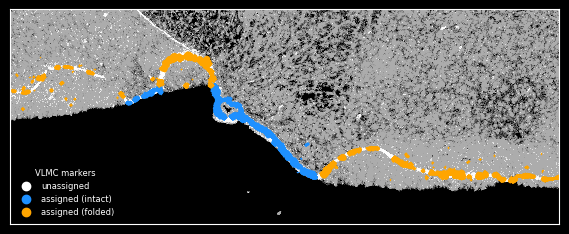

In [102]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm))

    scatter_kwargs = dict(x="x", y="y", rasterized=True, ax=ax, lw=0)

    sns.scatterplot(
        data=coordinate_df_3d[coordinate_df_3d.y.between(*ylim)],
        s=0.5,
        alpha=0.1,
        c="dimgrey",
        **scatter_kwargs
    )
    sns.scatterplot(
        data=coordinate_df_3d[
            lambda df: df.y.between(*ylim) & df.Gene.isin(endothelial_markers)
        ],
        s=0.5,
        alpha=0.5,
        c="white",
        **scatter_kwargs
    )
    sns.scatterplot(
        data=coordinate_df_3d_clean_vlmcs, s=1, c="dodgerblue", **scatter_kwargs
    )
    sns.scatterplot(data=coordinate_df_3d_fold_vlmcs, s=1, c="orange", **scatter_kwargs)

    plt.legend(
        handles=[
            plt.scatter([], [], c=c, label=l)
            for c, l in zip(
                ["white", "dodgerblue", "orange"],
                ["unassigned", "assigned (intact)", "assigned (folded)"],
            )
        ],
        title="VLMC markers",
        frameon=False,
        loc="lower left",
    )

    ax.set(**ax_kwargs, **ax_lims)

    fig.savefig("baysor_3d_vlmcs.svg", dpi=600)
    fig.savefig("baysor_3d_vlmcs.pdf", dpi=600)

In [75]:
coordinate_df_3d["celltypes_short"] = coordinate_df_3d.celltype.str.split(" ").str[-1]
coordinate_df_3d.loc[
    coordinate_df_3d["cluster"].str.contains("VLMC"), "celltypes_short"
] = "VLMC"
coordinate_df_3d["celltypes_short"] = coordinate_df_3d["celltypes_short"].astype(
    "category"
)

In [76]:
from matplotlib.cm import Set3

celltypes = coordinate_df_3d["celltypes_short"].cat.categories

cmap = dict(zip(celltypes, Set3(np.linspace(0, 0.93, len(celltypes)))))

In [77]:
ct_scatter_kwargs = dict(
    x="x",
    y="y",
    hue="celltypes_short",
    rasterized=True,
    palette=cmap,
    legend=False,
    lw=0,
)

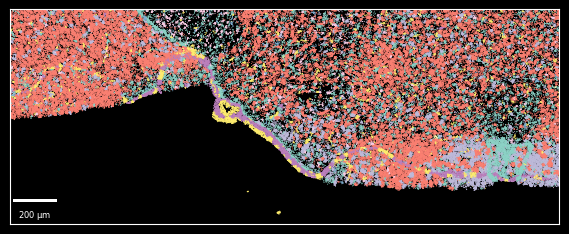

In [103]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm))

    sns.scatterplot(
        data=coordinate_df_3d[lambda df: df.y.between(*ylim) & df.x.between(*xlim)][
            ::10
        ],
        s=0.5,
        ax=ax,
        **ct_scatter_kwargs
    )

    ax.set(**ax_kwargs, **ax_lims)

    ax.add_artist(
        ScaleBar(1 / 4.7, units="um", frameon=False, color="w", loc="lower left")
    )

    fig.savefig("baysor_3d_celltypes.svg", dpi=600)
    fig.savefig("baysor_3d_celltypes.pdf", dpi=600)

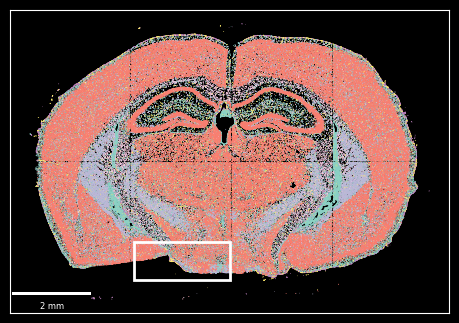

In [104]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(15 * cm, 10 * cm))

    sns.scatterplot(data=coordinate_df_3d[::50], s=0.2, ax=ax, **ct_scatter_kwargs)
    ax.set(**ax_kwargs)
    ax.add_artist(
        plt.Rectangle(
            (xlim[0], ylim[0]),
            xlim[1] - xlim[0],
            ylim[1] - ylim[0],
            fill=False,
            edgecolor="w",
            lw=2,
        )
    )
    ax.add_artist(
        ScaleBar(1 / 4.7, units="um", frameon=False, color="w", loc="lower left")
    )

    fig.savefig("baysor_3d_celltypes_global.svg", dpi=600)

/tmp/ipykernel_459281/4015738903.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles=[plt.scatter([], [], c=c, label=l) for l, c in cmap.items()],


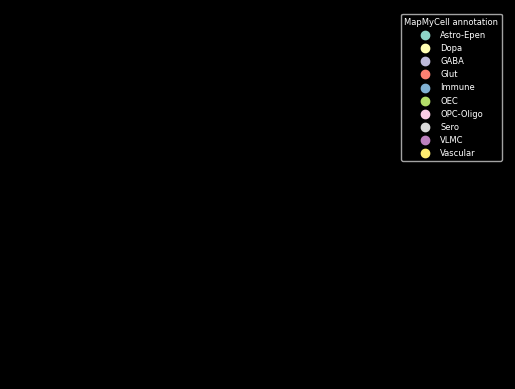

In [105]:
with plt.style.context("dark_background"):
    plt.legend(
        handles=[plt.scatter([], [], c=c, label=l) for l, c in cmap.items()],
        title="MapMyCell annotation",
    )
    plt.axis("off")

    plt.savefig("baysor_3d_celltypes_legend.svg", dpi=300)

#### Slice up the VLMC into a 'clean' and 'folded' part, show that we have DEGs that are e.g. Astrocyte markers;

In [22]:
import ovrlpy

coordinate_df_resized = (
    coordinate_df_3d.assign(gene=lambda df: df["Gene"].astype(str).astype("category"))
    .loc[:, ["gene", "x", "y", "z"]]
    .copy()
)
coordinate_df_resized[["x", "y", "z"]] = coordinate_df_resized[["x", "y", "z"]] / 4.7

brain = ovrlpy.Ovrlp(coordinate_df_resized, random_state=42, n_workers=16)
brain.process_coordinates(shift=False)
brain.fit_transcripts()
brain.compute_VSI()

determining pseudocells
found 57171 pseudocells
sampling expression:


100%|██████████| 54/54 [00:47<00:00,  1.13it/s]


Modeling 30 pseudo-celltype clusters;


100%|██████████| 315/315 [04:36<00:00,  1.14it/s]


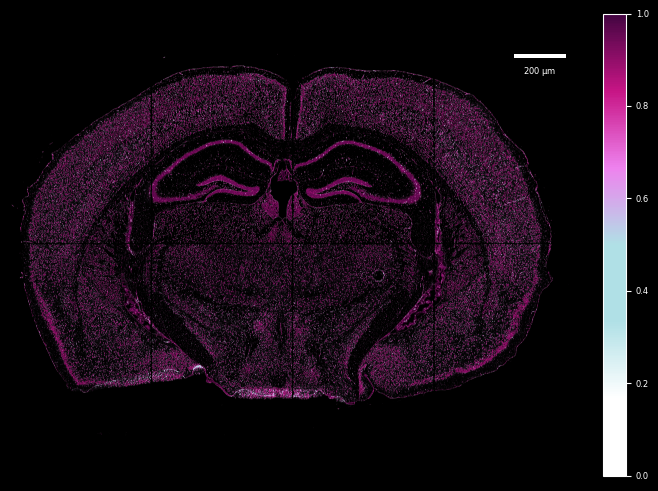

In [82]:
fig = ovrlpy.plot_signal_integrity(
    brain,
    signal_threshold=3,
    histogram=False,
    scalebar=dict(dx=1 / 4.7, units="um", frameon=False, color="w"),
)

ax = fig.axes[0]
ax.set_xticks([])
ax.set_yticks([])
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.savefig("baysor_3d_signal_integrity.svg", dpi=600)

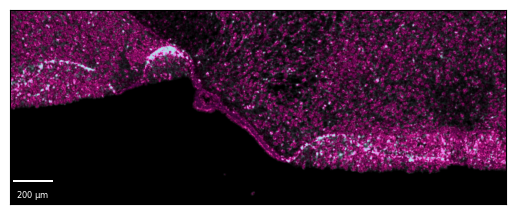

In [24]:
from ovrlpy._plotting import BIH_CMAP as cmap

fig, ax = plt.subplots()

xlim_rescaled = slice(*(int(x / 4.7) for x in xlim))
ylim_rescaled = slice(*(int(y / 4.7) for y in ylim))

integrity = brain.integrity_map.copy()
# integrity[brain.signal_map == 0] = np.nan

ax.imshow(
    integrity[ylim_rescaled, xlim_rescaled],
    alpha=(brain.signal_map[ylim_rescaled, xlim_rescaled] / 3).clip(0, 1),
    origin="lower",
    cmap=cmap,
)
ax.set_xticks([])
ax.set_yticks([])
ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", loc="lower left"))

_ = ax.set(facecolor="k")

In [25]:
signal_integrity = brain.integrity_map.copy()
signal_strength = brain.signal_map.copy()

In [26]:
signal_integrity[signal_strength == 0] = np.nan

dataset_3d["sampled_integrity"] = signal_integrity[
    (dataset_3d.centroid_y / 4.7).astype(int), (dataset_3d.centroid_x / 4.7).astype(int)
]
dataset_3d[
    "class_correlation_coefficient"
] = mapmycells_df_3d.class_correlation_coefficient[dataset_3d.index]

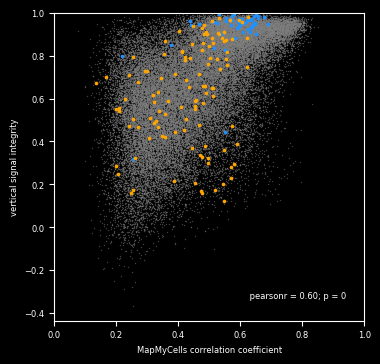

In [98]:
# add regression line?

from scipy.stats import pearsonr

isna = dataset_3d["sampled_integrity"].isna()
pearson, p = pearsonr(
    dataset_3d["class_correlation_coefficient"][~isna],
    dataset_3d["sampled_integrity"][~isna],
)


with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(4, 4))

    scatter_kwargs = dict(
        x="class_correlation_coefficient", y="sampled_integrity", lw=0, ax=ax
    )

    stitch_plain_vlmc_mask[isna] = False
    stitch_overlap_vlmc_mask[isna] = False

    sns.scatterplot(
        data=dataset_3d[stitch_mask], s=1, c="grey", alpha=0.5, **scatter_kwargs
    )

    sns.scatterplot(
        data=dataset_3d[stitch_plain_vlmc_mask], s=7, c="dodgerblue", **scatter_kwargs
    )
    sns.scatterplot(
        data=dataset_3d[stitch_overlap_vlmc_mask], s=7, c="orange", **scatter_kwargs
    )
    ax.set(
        xlabel="MapMyCells correlation coefficient",
        ylabel="vertical signal integrity",
        xlim=(0, 1),
        ylim=(None, 1),
    )
    ax.text(
        s=f" pearsonr = {pearson:.2f}; p = {p:.2g} ",
        ha="right",
        va="top",
        x=0.95,
        y=-0.3,
        color="w",
    )

fig.savefig("baysor_3d_integrity_correlation.svg", dpi=300)

In [28]:
from scipy.stats import chi2_contingency

vlmc_mask = stitch_plain_vlmc_mask | stitch_overlap_vlmc_mask

# Create a contingency table
contingency_table = pd.crosstab(
    (dataset_3d.loc[vlmc_mask, "class_correlation_coefficient"] > 0.5),
    (dataset_3d.loc[vlmc_mask, "sampled_integrity"] > 0.7),
)

# Perform the chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared test statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-squared test statistic: 38.616012287267836
p-value: 5.15939087303494e-10
Degrees of freedom: 1
Expected frequencies: [[34.81927711 50.18072289]
 [33.18072289 47.81927711]]


In [29]:
from scipy.stats import fisher_exact

fisher_exact(contingency_table, alternative="greater")

SignificanceResult(statistic=np.float64(9.58974358974359), pvalue=np.float64(9.053915525401988e-11))